# Benchmarking n2v transforms

To test:
- Mean and std masked pixels
- Uniformity of masking
- Correctness of the masking
- Across different batch for torch implementation


Obsrvations:
- numpy implementation of median is wrong as it only selects pixels on the edge
- torch implementation wiht batch 1 is faulty and selects an outrageous number of pixels
- sometimes the first batch has a singel pixel error (not sure yet)

Questions:
- Do pixels get replaced by values over batch in torch implementation?

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from careamics.config.transformations import N2VManipulateModel
from careamics.transforms import N2VManipulate, N2VManipulateTorch

/localscratch/mamba/envs/cmcs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# parameters
seed = 1798
strategy = "median"
n_images = 1000
z_depth = 32

In [4]:
# benchmarks methods
def n_masked_pixels(masks: np.ndarray | torch.Tensor) -> float:
    """Calculate the number of masked pixels in the masks.
    
    Masked pixels are non zero pixels in the masks. Arrays are expected to be of shape
    (C, (Z), Y, X), where Z is an optional dimension.
    """
    if isinstance(masks, torch.Tensor):
        masks = masks.cpu().numpy()

    # threshold
    masks = np.where(masks > 0, 1, 0)
    
    return np.sum(masks)


def uniformity(mask_list: np.ndarray | torch.Tensor) -> float:
    """Show mask uniformity by thresholding the mask and summing along batch.

    Shape C(Z)YX is expected, where Z is an optional dimension.
    """
    if isinstance(mask_list[0], torch.Tensor):
        mask_list = [mask.cpu().numpy() for mask in mask_list]

    # threshold masks
    mask_list = [np.where(mask > 0, 1, 0) for mask in mask_list]

    # add all masks
    all_masks = np.array(mask_list)
    mask_sum = np.sum(all_masks, axis=0)

    return mask_sum.squeeze() / len(mask_list)

# TODO how to deal with C? are the pixels masked in all channels?
# TODO how to deal with Z? are the pixels replaced within 3D voxels or in slice only?
def check_uniform_correctness(masked, original, mask, has_z = False, has_c = False, roi = 5) -> bool:
    """Check if the mask uniform replacement is correct."""
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy().squeeze()
    mask = mask.squeeze()

    if isinstance(original, torch.Tensor):
        original = original.cpu().numpy()
    original = original.squeeze()

    # loop over non-zero pixels in the mask
    indices = np.where(mask > 0)

    if has_z:
        for z, y, x in zip(*indices):
            val = masked[z, y, x]

            # stop indices at the edges
            y_min = max(0, y - roi)
            y_max = min(original.shape[1] - 1, y + roi)
            x_min = max(0, x - roi)
            x_max = min(original.shape[2] - 1, x + roi)
            z_min = max(0, z - roi)
            z_max = min(original.shape[0] - 1, z + roi)

            if val not in original[z_min:z_max + 1, y_min:y_max + 1, x_min:x_max + 1]:
                print(f"Incorrect value {val} at ({z}, {y}, {x}), (original value: {original[z, y, x]})")
                return False    
    else:
        for y, x in zip(*indices):
            val = masked[y, x]

            # stop indices at the edges
            y_min = max(0, y - roi)
            y_max = min(original.shape[0] - 1, y + roi)
            x_min = max(0, x - roi)
            x_max = min(original.shape[1] - 1, x + roi)

            if val not in original[y_min:y_max + 1, x_min:x_max + 1]:
                print(f"Incorrect value {val} at ({y}, {x}), (original value: {original[y, x]})")
                return False
            
    return True


def check_median_correctness(masked, original, mask, has_z = False, has_c = False, roi = 5) -> bool:
    """Check if the mask median replacement is correct."""
    if isinstance(masked, torch.Tensor):
        masked = masked.cpu().numpy()
    masked = masked.squeeze()

    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()
    mask = mask.squeeze()

    if isinstance(original, torch.Tensor):
        original = original.cpu().numpy()
    original = original.squeeze()

    # loop over non-zero pixels in the mask
    indices = np.where(mask > 0)


    if has_z:
        for z, y, x in zip(*indices):
            val = masked[z, y, x]

            # stop indices at the edges
            y_min = max(0, y - roi)
            y_max = min(original.shape[1] - 1, y + roi)
            x_min = max(0, x - roi)
            x_max = min(original.shape[2] - 1, x + roi)
            z_min = max(0, z - roi)
            z_max = min(original.shape[0] - 1, z + roi)

            # get the neighborhood
            neighborhood = original[z_min:z_max + 1, y_min:y_max + 1, x_min:x_max + 1]
            neighborhood_aslist = neighborhood.flatten().tolist()

            # remove the center pixel
            neighborhood_aslist.remove(original[z, y, x])

            median_val = np.median(neighborhood)

            if val != median_val:
                print(f"Incorrect value {val} at ({z}, {y}, {x}), expected {median_val} (original value: {original[z, y, x]})")
                return False
    
    else:
        for y, x in zip(*indices):
            val = masked[y, x]

            # stop indices at the edges
            y_min = max(0, y - roi)
            y_max = min(original.shape[0] - 1, y + roi)
            x_min = max(0, x - roi)
            x_max = min(original.shape[1] - 1, x + roi)

            # get the neighborhood
            neighborhood = original[y_min:y_max + 1, x_min:x_max + 1]
            neighborhood_aslist = neighborhood.flatten().tolist()

            # remove the center pixel
            neighborhood_aslist.remove(original[y, x])

            median_val = np.median(neighborhood)

            if val != median_val:
                print(f"Incorrect value {val} at ({y}, {x}), expected {median_val} (original value: {original[y, x]})")
                return False
            
    return True


def create_manipulators(strategy, seed):
    # numpy implementation
    n2v_manipulate = N2VManipulate(
        strategy=strategy,
        seed=None
    )

    # torch implementation
    n2v_manipulate_torch = N2VManipulateTorch(
        n2v_manipulate_config=N2VManipulateModel(
            strategy=strategy
        ),
        seed=None
    )

    assert n2v_manipulate_torch.masked_pixel_percentage == n2v_manipulate.masked_pixel_percentage
    assert n2v_manipulate_torch.roi_size == n2v_manipulate.roi_size
    assert n2v_manipulate_torch.strategy == n2v_manipulate.strategy
    assert n2v_manipulate_torch.remove_center == n2v_manipulate.remove_center

    # numpy implementation expects C(Z)YX
    # torch implementation expects BC(Z)YX

    return n2v_manipulate, n2v_manipulate_torch

## 2D case

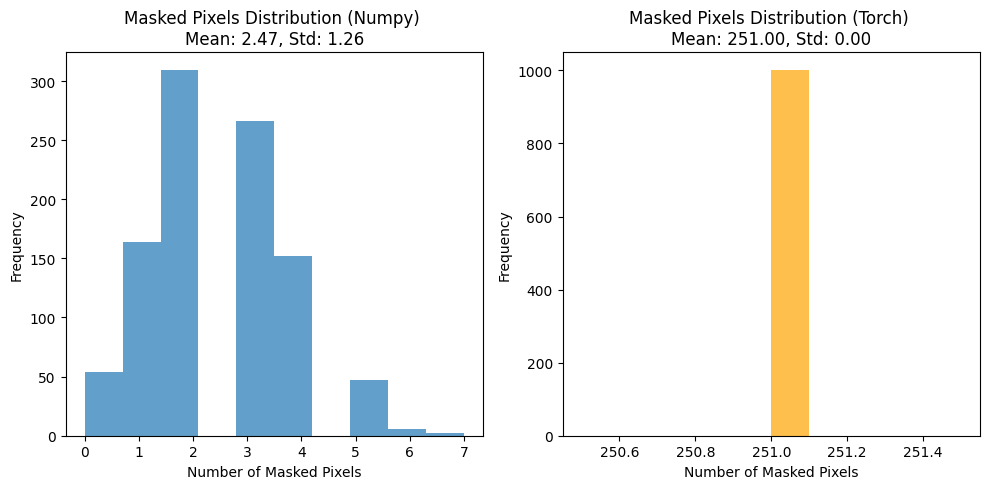

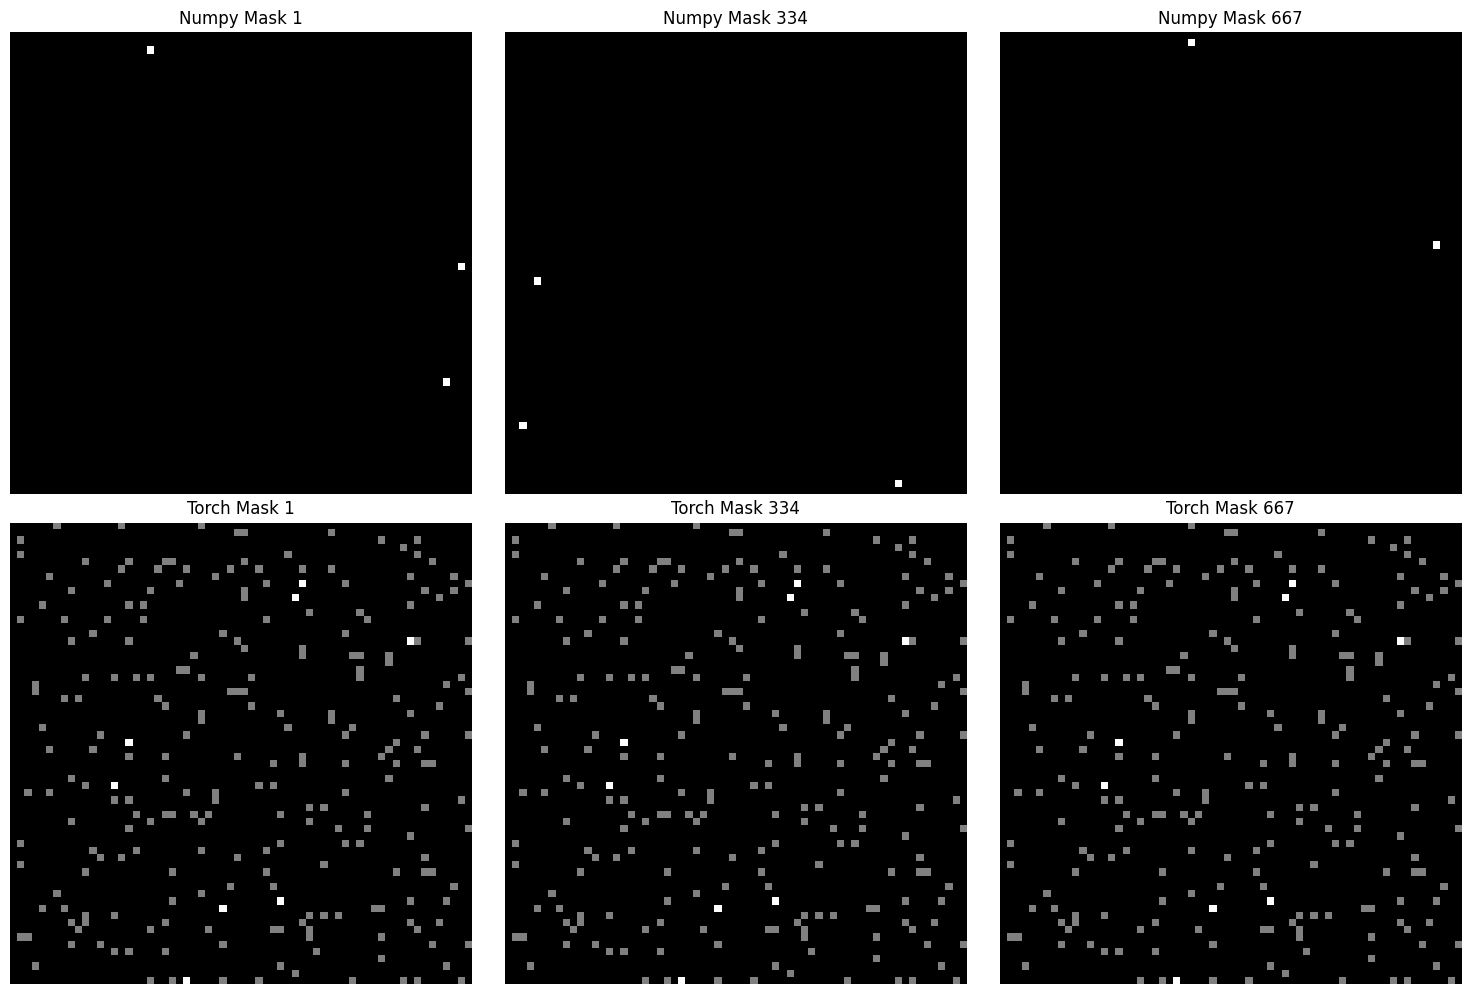

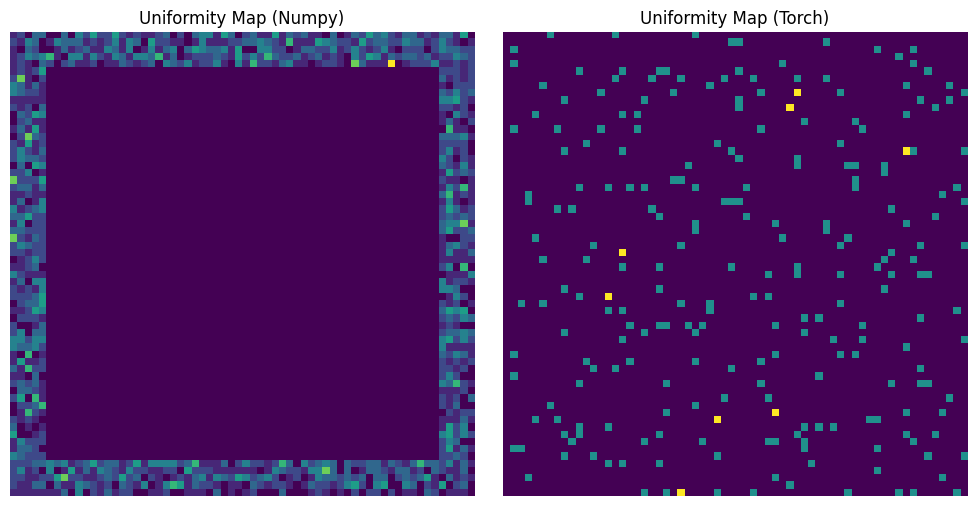

In [9]:
# benchmark mean number of masked pixels

# create numpy array
shape = (1, 64, 64) # CYX
bs = 32 # batch size for torch
data = np.arange(np.prod(shape)).reshape(shape)
data_torch = torch.from_numpy(data[np.newaxis, ...]).repeat(bs, 1, 1, 1).float()  # BCYX

n2v_manipulate, n2v_manipulate_torch = create_manipulators(strategy, seed)

masked_pix_np = []
masked_pix_torch = []
masked_np = []
masked_torch = []
masks_np = []
masks_torch = []

for i in range(n_images):
    # numpy implementation
    single_masked_np, _, mask_numpy = n2v_manipulate(data)
    masked_np.append(single_masked_np.squeeze())
    masks_np.append(mask_numpy)
    masked_pix_np.append(n_masked_pixels(mask_numpy))

    # torch implementation
    single_masked_torch, _, mask_torch = n2v_manipulate_torch(data_torch.cuda())
    masked_torch.append(single_masked_torch.cpu().numpy().squeeze())
    masks_torch.append(mask_torch)
    masked_pix_torch.append(n_masked_pixels(mask_torch))

map_np = uniformity(masks_np)
map_torch = uniformity(masks_torch)

# plot distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(masked_pix_np, alpha=0.7, label='Numpy Implementation')
plt.title(
    f'Masked Pixels Distribution (Numpy) \n'
    f'Mean: {np.mean(masked_pix_np):.2f}, Std: {np.std(masked_pix_np):.2f}'
)
plt.xlabel('Number of Masked Pixels')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(masked_pix_torch, alpha=0.7, label='Torch Implementation', color='orange')
plt.title(
    f'Masked Pixels Distribution (Torch) \n'
    f'Mean: {np.mean(masked_pix_torch):.2f}, Std: {np.std(masked_pix_torch):.2f}'
)
plt.xlabel('Number of Masked Pixels')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# plot 3 example masks
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i in range(3):
    ind = i*n_images // 3

    # numpy mask
    axes[0, i].imshow(masks_np[ind][0], cmap='gray')
    axes[0, i].set_title(f'Numpy Mask {ind+1}')
    axes[0, i].axis('off')

    # torch mask
    axes[1, i].imshow(masks_torch[ind].float().mean(0).cpu().numpy().squeeze(), cmap='gray')
    axes[1, i].set_title(f'Torch Mask {ind+1}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

# plot uniformity maps
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(map_np)
plt.title('Uniformity Map (Numpy)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(map_torch.astype('float').mean(0))
plt.title('Uniformity Map (Torch)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [27]:
avg_f = []
min_m = []
max_m = []
avg_l = []
for m in masks_torch:
    avg_f.append(torch.count_nonzero(m[1]).cpu().numpy())
    min_m.append(np.min(torch.count_nonzero(m[1:-1], dim=(1,2,3)).cpu().numpy()))
    max_m.append(np.max(torch.count_nonzero(m[1:-1], dim=(1,2,3)).cpu().numpy()))
    avg_l.append(torch.count_nonzero(m[-1]).cpu().numpy())
print("avg pix 0: ", np.mean(avg_f))
print("min pix m: ", np.mean(min_m))
print("max pix m: ", np.mean(max_m))
print("avg pix last: ", np.mean(avg_l))

avg pix 0:  5.0
min pix m:  2.0
max pix m:  15.0
avg pix last:  21.0


In [5]:
if strategy == "median":
    function_check = check_median_correctness
else:
    function_check = check_uniform_correctness

# check correctness of the masks
print(f"------ Numpy: Checking correctness of the masks ---")
for i, m in enumerate(masks_np):
    if not function_check(masked_np[i], data[0], m):
        print(f"Numpy mask is incorrect! Index: {i}")
        break

print(f"------ Torch: Checking correctness of the masks ---")
for i, m in enumerate(masks_torch):
    if not function_check(masked_torch[i], data_torch[0], m):
        print(f"Torch mask is incorrect! Index: {i}")
        break


------ Numpy: Checking correctness of the masks ---
Incorrect value 3728 at (59, 11), expected 3755.0 (original value: 3787)
Numpy mask is incorrect! Index: 0
------ Torch: Checking correctness of the masks ---


ValueError: too many values to unpack (expected 2)

In [ ]:
# investigate torch across batches
masked_pix_number = []
maps_mask = []
mask_batches = []
masked_batches = []
original_batches = []

_, n2v_manipulate_torch = create_manipulators(strategy, seed)

# batch 1, 8, 16, 32
batch_sizes = [1, 8, 16, 32]
for batch_size in batch_sizes:

    masks_batch = []
    masked_pix_batch = []
    masked_batch = []
    original_batch = []
    n = 0
    while n < n_images:
        n += batch_size
    
        # create numpy array
        shape = (batch_size, 1, 64, 64)  # BCYX
        data = np.arange(np.prod(shape)).reshape(shape)

        # torch implementation
        masked_patch, original, mask_torch = n2v_manipulate_torch(torch.from_numpy(data))
        
        debatched = [mask_torch[i] for i in range(batch_size)]
        masks_batch.extend(debatched)
        masked_pix_batch.extend([n_masked_pixels(m) for m in debatched])

        debatched_masked = [masked_patch[i].cpu().numpy().squeeze() for i in range(batch_size)]
        masked_batch.extend(debatched_masked)

        debatched_original = [original[i].cpu().numpy().squeeze() for i in range(batch_size)]
        original_batch.extend(debatched_original)
    
    mask_batches.append(masks_batch)
    masked_batches.append(masked_batch)
    masked_pix_number.append(masked_pix_batch)
    maps_mask.append(uniformity(masks_batch))
    original_batches.append(original_batch)

In [ ]:
print(f"Number of images averaged: {[len(m) for m in masked_pix_number]}")

In [ ]:
# plot histograms of number of masked pixels for each batch size
plt.figure(figsize=(20, 5))
plt.subplot(1, len(batch_sizes), 1)
for i, batch_size in enumerate(batch_sizes):
    plt.subplot(1, len(batch_sizes), i + 1)

    plt.hist(masked_pix_number[i], alpha=0.7)
    plt.title(
        f'Batch Size {batch_size}\n'
        f'Masked Pixels: {np.mean(masked_pix_number[i]):.2f}'
    )
    plt.xlabel('Number of Masked Pixels')
    plt.ylabel('Frequency')


# plot average uniformity maps for each batch size
plt.figure(figsize=(20, 5))
for i, batch_size in enumerate(batch_sizes):
    plt.subplot(1, len(batch_sizes), i + 1)
    plt.imshow(maps_mask[i])
    plt.title(f'Uniformity Map (Batch Size {batch_size})')
    plt.axis('off')

In [ ]:
# check correctness of batched torch
for i, batch in enumerate(batch_sizes):
    print(f"------ Torch: Checking correctness of the masks for batch size {batch} ---")

    for j, m in enumerate(mask_batches[i]):
        if not function_check(masked_batches[i][j], original_batches[i][j], m):
            print(f"Torch mask {j} of batch {batch} is incorrect!")
            break



## 3D case

In [ ]:
# investigate torch across batches
masked_pix_number = []
maps_mask = []
masks_batches = []
masked_batches = []
original_batches = []

_, n2v_manipulate_torch = create_manipulators(strategy, seed)

# batch 1, 8, 16, 32
batch_sizes = [1, 8, 16, 32]
for batch_size in batch_sizes:

    masked_pix_batch = []
    masks_batch = []
    masked_batch = []
    original_batch = []
    
    n = 0
    while n < n_images:
        n += batch_size
    
        # create numpy array
        shape = (batch_size, 1, z_depth, 64, 64)  # BCYX
        data = np.arange(np.prod(shape)).reshape(shape)

        # torch implementation
        masked_patch, orig_patch, mask_torch = n2v_manipulate_torch(torch.from_numpy(data))
        
        debatched = [mask_torch[i] for i in range(batch_size)]
        masks_batch.extend(debatched)
        masked_pix_batch.extend([n_masked_pixels(m) for m in debatched])

        debatched_masked = [masked_patch[i].cpu().numpy().squeeze() for i in range(batch_size)]
        masked_batch.extend(debatched_masked)
        debatched_original = [orig_patch[i].cpu().numpy().squeeze() for i in range(batch_size)]
        original_batch.extend(debatched_original)
    
    masked_pix_number.append(masked_pix_batch)
    maps_mask.append(uniformity(masks_batch))
    masked_batches.append(masked_batch)
    original_batches.append(original_batch)
    masks_batches.append(masks_batch)

In [ ]:
print(f"Expected number of masked pixels: {32*64*64*0.2/100}")

# plot histograms of number of masked pixels for each batch size
plt.figure(figsize=(20, 5))
plt.subplot(1, len(batch_sizes), 1)
for i, batch_size in enumerate(batch_sizes):
    plt.subplot(1, len(batch_sizes), i + 1)

    plt.hist(masked_pix_number[i], alpha=0.7)
    plt.title(
        f'Batch Size {batch_size}\n'
        f'Masked Pixels: {np.mean(masked_pix_number[i]):.2f}'
    )
    plt.xlabel('Number of Masked Pixels')
    plt.ylabel('Frequency')


# plot average uniformity maps for each batch size
plt.figure(figsize=(20, 20))
for i, batch_size in enumerate(batch_sizes):
    for j in range(4):
        # loop over z
        ind_z = j * z_depth // 4
        plt.subplot(len(batch_sizes), 4, i * 4 + j + 1)
        plt.imshow(maps_mask[i][ind_z])
        plt.title(f'Uniformity Map (Batch Size {batch_size}, Z {ind_z})')
    plt.axis('off')
    plt.tight_layout()

In [ ]:
# check correctness of batched torch
for i, batch in enumerate(batch_sizes):
    print(f"------ Torch: Checking correctness of the masks for batch size {batch} ---")

    for j, m in enumerate(masks_batches[i]):
        if not function_check(masked_batches[i][j], original_batches[i][j], m, has_z=True):
            print(f"Torch mask {j} of batch {batch} is incorrect!")
            break



## 2D with Channel

## 3D with Channel